In [25]:
mkdir -p ~/.kaggle && echo KGAT_9a9eb9d2374ba472441bd2da6b1ac6d7 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [26]:
%%bash
kaggle datasets download sunilthite/cat-or-dog-image-classification

Dataset URL: https://www.kaggle.com/datasets/sunilthite/cat-or-dog-image-classification
License(s): other
cat-or-dog-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [27]:
import zipfile
zip_ref = zipfile.ZipFile('cat-or-dog-image-classification.zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [28]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [29]:

train_ds = keras.utils.image_dataset_from_directory(
  directory = '/content/Train',
  labels='inferred',
  label_mode = 'int',
  batch_size=32,
  image_size=(256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
  directory = '/content/Test',
  labels='inferred',
  label_mode = 'int',
  batch_size=32,
  image_size=(256,256)
)


Found 23650 files belonging to 2 classes.
Found 3863 files belonging to 2 classes.


In [30]:
def process(image, label):
    image = tf.cast(image / 255. ,tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [31]:
model = Sequential()

In [32]:
from keras.layers import BatchNormalization, Dropout

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))


model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))



model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))



model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1)) # Added Dropout layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1)) # Added Dropout layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 74s 91ms/step - accuracy: 0.5519 - loss: 1.2857 - val_accuracy: 0.5674 - val_loss: 0.6657
Epoch 2/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 65s 87ms/step - accuracy: 0.5862 - loss: 0.6650 - val_accuracy: 0.6472 - val_loss: 0.6103
Epoch 3/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 0.6303 - loss: 0.6355 - val_accuracy: 0.6648 - val_loss: 0.6176
Epoch 4/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 0.6753 - loss: 0.6101 - val_accuracy: 0.6961 - val_loss: 0.6620
Epoch 5/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 65s 87ms/step - accuracy: 0.6852 - loss: 0.5998 - val_accuracy: 0.5985 - val_loss: 0.6655
Epoch 6/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 0.7041 - loss: 0.5721 - val_accuracy: 0.6637 - val_loss: 0.6382
Epoch 7/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 87ms/step - accuracy: 0.7156 - loss: 0.5645 - val_accuracy: 0.7484 - val_loss: 0.5331
Epoch 8/10
740/740 ━━━━━━━━━━━━━━━━━━━━ 64s 86ms/step - accuracy: 0.7202 - loss: 0.5582 - 

Plotting Training and Validation Accuracy

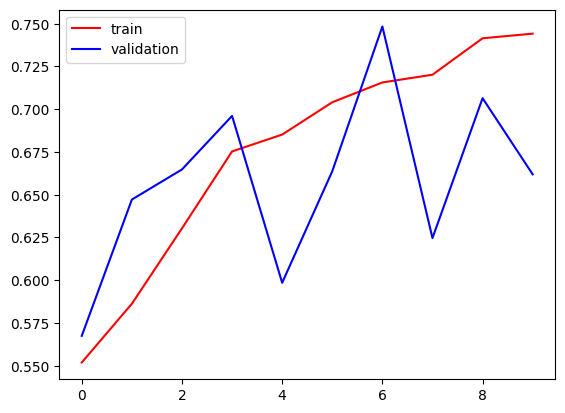

In [36]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

Plotting Training and Validation Loss

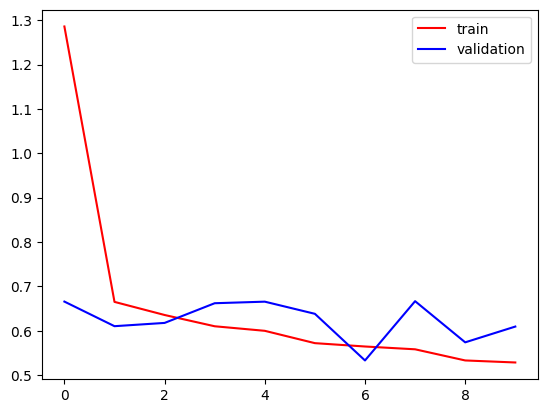

In [37]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')